# Overlay study — multi-asset chento, wick-exit, half-risk tag, post-loss throttle

See `findings.md` for the write-up. Verdicts: multi-asset BTC+ETH **yes** (diversification real); wick-exit **no** (cuts the 6R tail); half-risk tag **no as specified** (tags 54% of trades); post-loss: shipped skip-after-loss best MAR, half-after-loss best income/DD compromise (and better on ETH).

*Absolute Rs inherit the research-pool lookahead; relative comparisons are the finding.*

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.width', 200)
res = pd.read_csv('results/overlay_summary.csv')
cols = ['variant','n','traded_n','mean_r','total_r','max_dd_r','mar_like','wr_pct','is_total_r','oos_total_r']
for scope in ('BTC','ETH','COMBINED'):
    sub = res[res.scope==scope]
    base = sub[sub.variant=='base|tilt=none|H=off'][cols].round(2)
    top = sub.sort_values('mar_like', ascending=False)[cols].head(8).round(2)
    print(f'=== {scope} baseline ==='); display(base)
    print(f'=== {scope} top by MAR ==='); display(top)


=== BTC baseline ===


,variant,n,traded_n,mean_r,total_r,max_dd_r,mar_like,wr_pct,is_total_r,oos_total_r
0,base|tilt=none|H=off,203,203,1.56,317.5,-7.9,40.18,57.14,223.62,93.88


=== BTC top by MAR ===


,variant,n,traded_n,mean_r,total_r,max_dd_r,mar_like,wr_pct,is_total_r,oos_total_r
2,base|tilt=skip_after_loss|H=off,203,117,1.80,211.05,-2.18,96.62,63.25,138.93,72.13
3,base|tilt=skip_after_loss|H=on,203,117,1.34,156.74,-2.43,64.45,63.25,98.86,57.87
7,base|tilt=half_after_2stops_7d|H=on,203,203,1.21,246.54,-4.15,59.37,57.14,168.58,77.96
5,base|tilt=half_after_loss|H=on,203,203,1.00,202.97,-3.45,58.81,57.14,135.31,67.66
4,base|tilt=half_after_loss|H=off,203,203,1.30,264.28,-4.95,53.37,57.14,181.28,83.00
36,wick_p3|tilt=half_after_loss|H=off,203,203,0.90,182.76,-3.64,50.23,58.62,121.35,61.41
39,wick_p3|tilt=half_after_2stops_7d|H=on,203,203,0.82,166.58,-3.34,49.88,58.62,112.47,54.12
34,wick_p3|tilt=skip_after_loss|H=off,203,120,1.24,149.19,-3.00,49.73,63.33,94.69,54.50


=== ETH baseline ===


...

,variant,n,traded_n,mean_r,total_r,max_dd_r,mar_like,wr_pct,is_total_r,oos_total_r
44,base|tilt=half_after_loss|H=off,143,143,1.39,198.37,-2.86,69.36,59.44,173.63,24.73
76,wick_p3|tilt=half_after_loss|H=off,143,143,1.07,153.36,-2.50,61.34,61.54,128.28,25.08
40,base|tilt=none|H=off,143,143,1.65,236.42,-4.00,59.11,59.44,204.38,32.04
46,base|tilt=half_after_2stops_7d|H=off,143,143,1.64,234.92,-4.00,58.73,59.44,201.88,33.04
45,base|tilt=half_after_loss|H=on,143,143,0.90,128.76,-2.50,51.50,59.44,106.87,21.89
68,wick_p2|tilt=half_after_loss|H=off,143,143,0.82,116.57,-2.50,46.63,62.94,95.29,21.28
78,wick_p3|tilt=half_after_2stops_7d|H=off,143,143,1.26,180.44,-4.00,45.11,61.54,146.56,33.88
72,wick_p3|tilt=none|H=off,143,143,1.26,180.04,-4.00,45.01,61.54,147.16,32.88


=== COMBINED baseline ===


,variant,n,traded_n,mean_r,total_r,max_dd_r,mar_like,wr_pct,is_total_r,oos_total_r
80,base|tilt=none|H=off,333,333,1.66,553.83,-8.0,69.23,58.86,428.0,125.83


=== COMBINED top by MAR ===


,variant,n,traded_n,mean_r,total_r,max_dd_r,mar_like,wr_pct,is_total_r,oos_total_r
83,base|tilt=skip_after_loss|H=on,333,196,1.50,294.25,-2.09,140.64,68.88,213.05,81.20
82,base|tilt=skip_after_loss|H=off,333,196,2.11,414.49,-3.18,130.17,68.88,313.39,101.10
84,base|tilt=half_after_loss|H=off,333,333,1.45,484.16,-4.50,107.59,58.86,370.70,113.46
115,wick_p3|tilt=skip_after_loss|H=on,333,202,1.03,207.73,-2.09,99.29,68.32,149.26,58.47
85,base|tilt=half_after_loss|H=on,333,333,1.05,348.85,-3.68,94.75,58.86,256.24,92.61
114,wick_p3|tilt=skip_after_loss|H=off,333,202,1.45,293.59,-3.18,92.20,68.32,219.58,74.02
86,base|tilt=half_after_2stops_7d|H=off,333,333,1.63,542.50,-6.00,90.42,58.86,414.18,128.33
116,wick_p3|tilt=half_after_loss|H=off,333,333,1.04,344.93,-4.00,86.23,60.66,257.37,87.56


## Cumulative R per asset (base exits, no overlays)

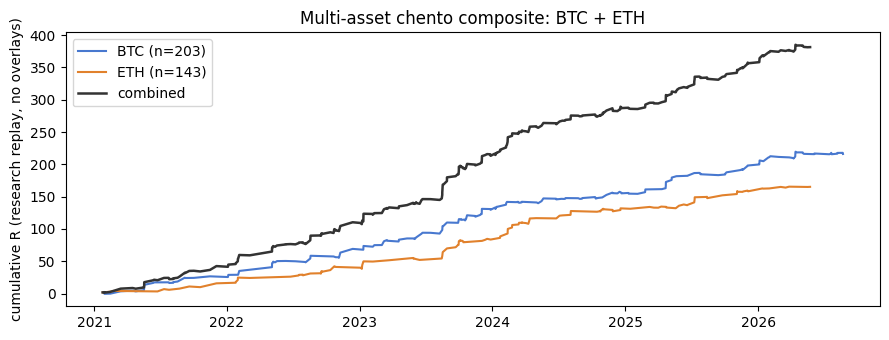

In [2]:
bt = pd.read_csv('results/trades_BTC.csv', parse_dates=['ts'])
et = pd.read_csv('results/trades_ETH.csv', parse_dates=['ts'])
for t in (bt, et):
    t['aligned'] = (((t.direction=='long') & (t.okx_delta_z>=0)) | ((t.direction=='short') & (t.okx_delta_z<=0)))
bt, et = bt[bt.aligned], et[et.aligned]
end = min(bt.ts.max(), et.ts.max())
comb = pd.concat([bt[bt.ts<=end], et[et.ts<=end]]).sort_values('ts')
fig, ax = plt.subplots(figsize=(9,3.5))
ax.plot(bt.ts, bt.r_outcome.cumsum(), label=f'BTC (n={len(bt)})', color='#4878cf')
ax.plot(et.ts, et.r_outcome.cumsum(), label=f'ETH (n={len(et)})', color='#e1812c')
ax.plot(comb.ts, comb.r_outcome.cumsum(), label='combined', color='#333', lw=1.8)
ax.legend(); ax.set_ylabel('cumulative R (research replay, no overlays)')
ax.set_title('Multi-asset chento composite: BTC + ETH')
plt.tight_layout()
